In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

In [2]:
df = pd.read_csv('/content/Salary Data.csv')

In [3]:
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [5]:
df.isnull().sum()
print(df.isnull().sum())

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64


In [6]:
df.duplicated().sum()
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

50
0


In [7]:
# fill numerical columns with mean
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Salary'] = df['Salary'].fillna(df['Salary'].mean())
df['Years of Experience'] = df['Years of Experience'].fillna(df['Years of Experience'].mean())

# fill mode for object data type
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Job Title'] = df['Job Title'].fillna(df['Job Title'].mode()[0])
df['Education Level'] = df['Education Level'].fillna(df['Education Level'].mode()[0])

In [8]:
df.isnull().sum()
print(df.isnull().sum())

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


In [9]:
from sklearn.preprocessing import LabelEncoder

# 2. Convert OBJECTS to INT using Label Encoding (Keeping it in 1 column per feature)
le = LabelEncoder()

# We encode these three columns into integers 0, 1, 2...
df['Gender'] = le.fit_transform(df['Gender'])
df['Education Level'] = le.fit_transform(df['Education Level'])
df['Job Title'] = le.fit_transform(df['Job Title'])

# 3. Ensure numerical columns are proper integers
df['Age'] = df['Age'].astype(int)
df['Salary'] = df['Salary'].astype(int)
df['Years of Experience'] = df['Years of Experience'].astype(int)

In [10]:
df.dtypes

,0
Age,int64
Gender,int64
Education Level,int64
Job Title,int64
Years of Experience,int64
Salary,int64


In [11]:
df = df.astype(int)
print(df.dtypes)

Age                    int64
Gender                 int64
Education Level        int64
Job Title              int64
Years of Experience    int64
Salary                 int64
dtype: object


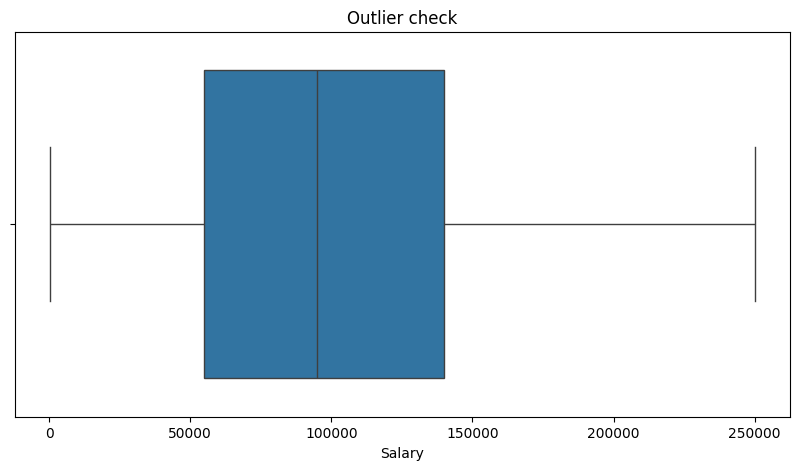

In [12]:
# box plot

plt.figure(figsize=(10,5))
sns.boxplot(x=df['Salary'])
plt.title("Outlier check")
plt.show()



In [13]:
print("---Lowest Salaries----")
print(df["Salary"].sort_values().head(5))

print("\n---Highest Salaries----")
print(df["Salary"].sort_values().tail(5))

---Lowest Salaries----
259      350
82     30000
283    35000
18     35000
218    35000
Name: Salary, dtype: int64

---Highest Salaries----
4      200000
53     200000
105    220000
83     250000
30     250000
Name: Salary, dtype: int64


In [14]:
# divide the target variable , & independent variable
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score

X =df.drop('Salary', axis=1)
y =df['Salary']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20, random_state = 42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(260, 5)
(65, 5)
(260,)
(65,)


In [15]:
model = LinearRegression()
model



LinearRegression()

In [16]:
model.fit(X_train,y_train)


LinearRegression()

In [17]:
y_pred = model.predict(X_test)

# check the results
print(f"Mean Absolute Error: {mean_absolute_error(y_pred,y_test)}")
print(f"Mean Squared Error:{mean_squared_error(y_pred,y_test)}")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_pred,y_test))}")
print(f"R2 Score:{r2_score(y_test,y_pred)}")

Mean Absolute Error: 9267.152368977791
Mean Squared Error:148642188.13942987
Root Mean Squared Error: 12191.890261129727
R2 Score:0.9348878451349295


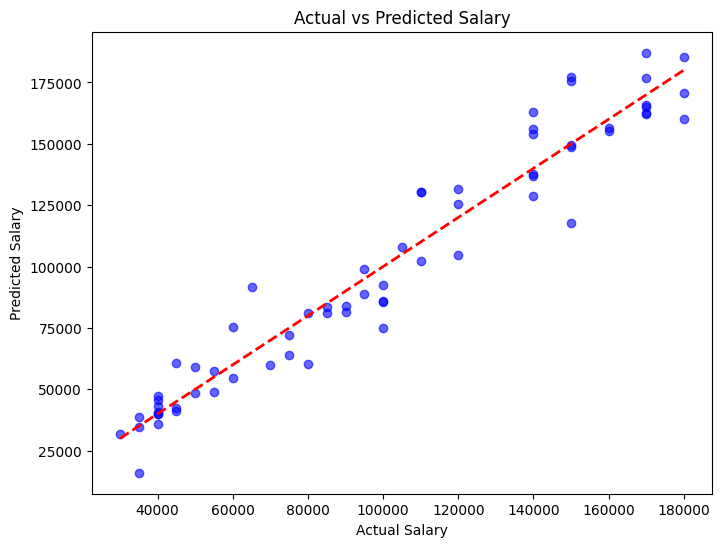

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color = 'blue',alpha =0.6)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--',lw=2)
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Actual vs Predicted Salary')
plt.show()


In [19]:
new_data = pd.DataFrame({
    'Age': [30],
    'Gender': [1],
    'Education Level': [2],
    'Job Title': [3],
    'Years of Experience': [5]
})

# ask the model for a prediction

prediction = model.predict(new_data)

print("----realtime salary prediction----")
print(f"Predicted Salary: {prediction[0]:,.2f}")

----realtime salary prediction----
Predicted Salary: 89,701.73


In [20]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Calculate more descriptive metrics
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"--- Model Performance Report ---")
print(f"R-Squared (Accuracy): {r2:.2f}")
print(f"Mean Absolute Error: ${mae:.2f}")
print(f"Root Mean Squared Error: ${rmse:.2f}")

--- Model Performance Report ---
R-Squared (Accuracy): 0.93
Mean Absolute Error: $9267.15
Root Mean Squared Error: $12191.89


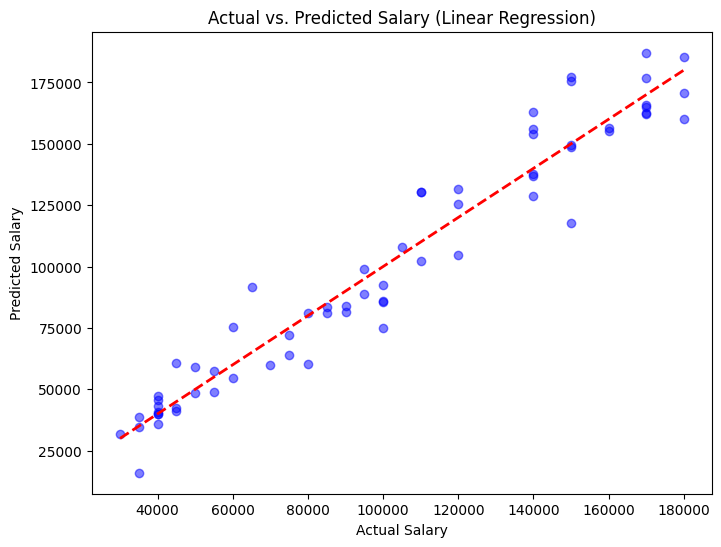

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Actual vs. Predicted Salary (Linear Regression)')
plt.show()

In [22]:
# Get coefficients for each feature
importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
importance = importance.sort_values(by='Coefficient', ascending=False)

print("\n--- Feature Impact on Salary ---")
print(importance)


--- Feature Impact on Salary ---
               Feature   Coefficient
2      Education Level  16022.171731
1               Gender   8342.049581
0                  Age   3169.950657
4  Years of Experience   2467.271404
3            Job Title     20.549967


In [23]:
def predict_salary_tool():
    print("--- Salary Predictor Tool ---")
    age = int(input("Enter Age: "))
    gender = int(input("Gender (0 for Female, 1 for Male): "))
    edu = int(input("Education (0:Bach, 1:Mast, 2:PhD): "))
    job = int(input("Job Title Code: "))
    exp = int(input("Years of Experience: "))

    features = pd.DataFrame([[age, gender, edu, job, exp]],
                            columns=['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience'])
    prediction = model.predict(features)
    print(f"\nPredicted Market Salary: ${prediction[0]:,.2f}")

# Uncomment to run in the notebook:
# predict_salary_tool()

In [24]:
comparison_df = pd.DataFrame({'Actual Salary': y_test, 'Predicted Salary': y_pred})
comparison_df['Difference'] = comparison_df['Actual Salary'] - comparison_df['Predicted Salary']
print(comparison_df.head(10).round(2))

     Actual Salary  Predicted Salary  Difference
235          45000          60501.24   -15501.24
110         110000         130453.97   -20453.97
249         170000         165132.64     4867.36
9           110000         130418.53   -20418.53
93          170000         187113.89   -17113.89
220         170000         165814.77     4185.23
301          55000          57269.64    -2269.64
199         110000         102460.34     7539.66
204          90000          83789.93     6210.07
101          95000          98801.17    -3801.17
